# GAT — Standalone Convergence Diagnostic

Isolated from the full AgroVedha notebook to test GAT's behavior with an extended training budget. In the full-notebook run (5 epochs), GAT scored **RMSE=4.4769, R2=0.8177**. This notebook lets you push epochs higher and watch the loss curve directly.


## Setup — Load data, build graph, build windows (same as main notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [2]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [3]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)

y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [4]:
!pip install torch_geometric --no-deps -q
!pip install networkx decorator six -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.9 MB/s eta 0:00:0000:01


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

batch_size = 128
n_batches = len(X_train_t) // batch_size
loss_fn = nn.MSELoss()

Using device: cpu


## GAT Model

Same architecture as the main notebook (2-layer GAT, 2 attention heads, edge-weighted via `edge_dim=1`) — no structural changes here, this notebook is purely about testing whether **more training** closes the gap to GCN, or whether the gap is architectural (attention adding instability on a 6-node graph, as originally hypothesized).


In [6]:
from torch_geometric.nn import GATConv

class GATForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, heads=2):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, edge_dim=1)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, edge_dim=1)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index, edge_weight):
        edge_attr = edge_weight.unsqueeze(-1)
        outs = []
        for b in range(x.shape[0]):
            h = F.elu(self.gat1(x[b], edge_index, edge_attr))
            h = F.elu(self.gat2(h, edge_index, edge_attr))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

print("GAT model class defined.")

GAT model class defined.


## Extended Training — watch the loss curve

Set `N_EPOCHS` as high as your patience/session time allows — 30 is a starting point (6x the original 5-epoch run). Loss is printed every epoch; a log-scale plot follows to make plateaus/instability easy to spot.


In [7]:
N_EPOCHS = 30  # increase further if this still hasn't plateaued

model = GATForecaster(in_channels=WINDOW).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []

model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_t))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
        optimizer.zero_grad()
        pred = model(xb, edge_index_dev, edge_weight_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{N_EPOCHS}: loss={avg_loss:.6f}")

Epoch   1/30: loss=0.025064
Epoch   2/30: loss=0.013613
Epoch   3/30: loss=0.003723
Epoch   4/30: loss=0.002026
Epoch   5/30: loss=0.001352
Epoch   6/30: loss=0.001104
Epoch   7/30: loss=0.000936
Epoch   8/30: loss=0.000866
Epoch   9/30: loss=0.000756
Epoch  10/30: loss=0.000751
Epoch  11/30: loss=0.000726
Epoch  12/30: loss=0.000619
Epoch  13/30: loss=0.000650
Epoch  14/30: loss=0.000580
Epoch  15/30: loss=0.000542
Epoch  16/30: loss=0.000543
Epoch  17/30: loss=0.000555
Epoch  18/30: loss=0.000520
Epoch  19/30: loss=0.000477
Epoch  20/30: loss=0.000488
Epoch  21/30: loss=0.000478
Epoch  22/30: loss=0.000484
Epoch  23/30: loss=0.000455
Epoch  24/30: loss=0.000466
Epoch  25/30: loss=0.000465
Epoch  26/30: loss=0.000438
Epoch  27/30: loss=0.000425
Epoch  28/30: loss=0.000411
Epoch  29/30: loss=0.000405
Epoch  30/30: loss=0.000410


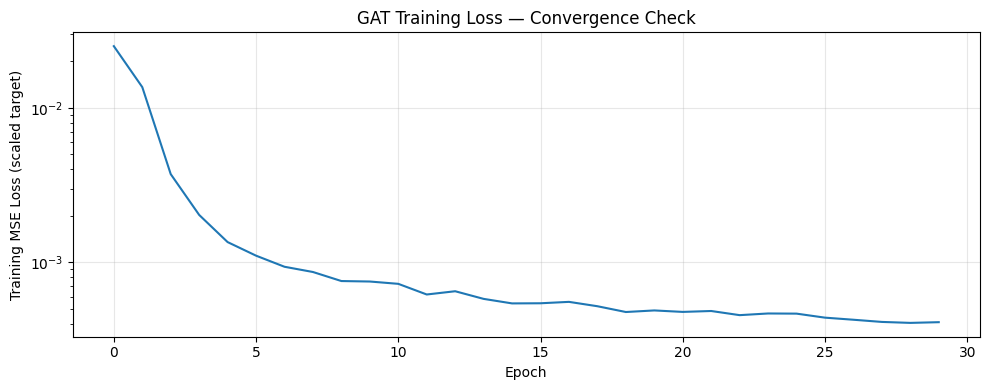


First 5 epochs avg loss: 0.009156
Last 5 epochs avg loss:  0.000418
Loss still decreasing in final 5 epochs: True


In [14]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss (scaled target)")
plt.title(f"GAT Training Loss — Convergence Check")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation on held-out test set

Compare this R² directly against the original 5-epoch run (RMSE=4.4769, R2=0.8177) to see how much (if any) extended training closes the gap.


In [15]:
def eval_model(m):
    m.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            xb = X_test_t[i:i+batch_size].to(device)
            preds.append(m(xb, edge_index_dev, edge_weight_dev).cpu().numpy())
    pred_scaled = np.concatenate(preds).flatten()
    return target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

pred = eval_model(model)
rmse, mae, r2 = eval_metrics(y_true_g, pred)

print(f"GAT ({N_EPOCHS} epochs) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
print()
print("For reference:")
print(f"  Original run (5 epochs):  RMSE=4.4769  R2=0.8177")

GAT (30 epochs) — RMSE: 1.2284  MAE: 0.7097  R2: 0.9863

For reference:
  Original run (5 epochs):  RMSE=4.4769  R2=0.8177


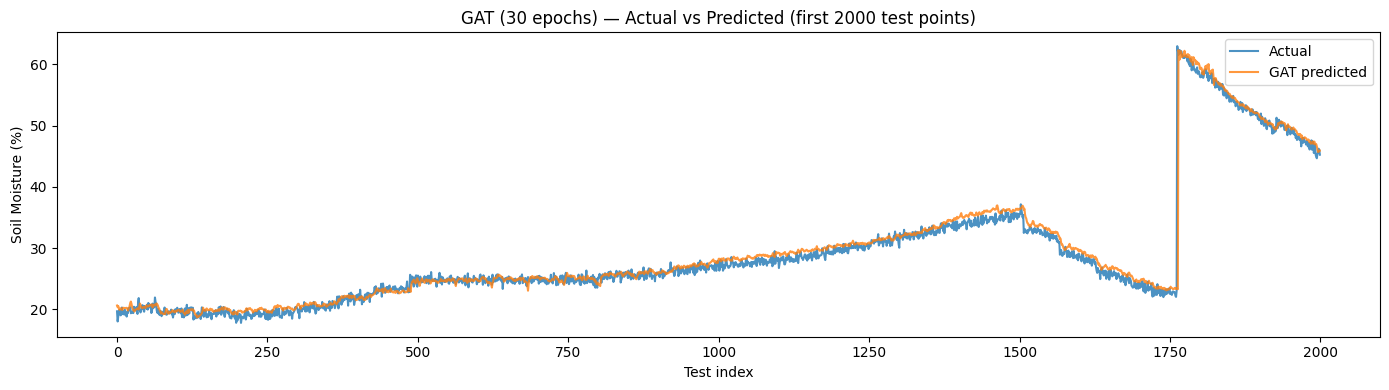

In [16]:
plt.figure(figsize=(14, 4))
plt.plot(y_true_g[:2000], label="Actual", alpha=0.8)
plt.plot(pred[:2000], label="GAT predicted", alpha=0.8)
plt.title(f"GAT ({N_EPOCHS} epochs) — Actual vs Predicted (first 2000 test points)")
plt.xlabel("Test index")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Interpreting the result

- **If loss drops substantially and R² approaches GCN's ~0.987**: the original 5-epoch run was simply undertrained — attention itself isn't the problem, it just needs more steps to stabilize than GCN's simpler aggregation. Report this as: *"GAT required more training epochs than GCN to reach comparable performance, consistent with its larger parameter count from multi-head attention."*
- **If loss plateaus early at a worse level than GCN, or stays noisy/unstable**: this supports the original hypothesis — attention's extra parameterization is a genuine liability on a 6-node graph, not just a training-budget artifact. Report this as: *"Even with extended training, GAT did not close the performance gap to GCN, suggesting attention mechanisms provide limited benefit — and possibly add instability — on small, densely-connected graphs like this one."*

Either outcome is a valid, useful finding — the point of this notebook is to determine which one it is with evidence, rather than assuming.
